# To save storage space, only the processed mean counts are included in the repository, not the raw data. This processing notebook is included for transparency. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import os
import scanpy as sc
from scipy.stats import linregress

import matplotlib as mpl

from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,scipy,seaborn"))

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
xenium_adata = sc.read_10x_h5('Xenium_mouse_brain/Xenium_Prime_Mouse_Brain_Coronal_FF_outs/cell_feature_matrix.h5')
xenium_mean_cnts = xenium_adata.to_df().mean()

In [3]:
xenium_adata

AnnData object with n_obs × n_vars = 63173 × 5006
    var: 'gene_ids', 'feature_types', 'genome'

In [4]:
xenium_mean_cnts.sum()

np.float32(1369.6624)

In [5]:
sfb = pd.read_csv('ReedSolomon_seqFISH_mouse_cortex/sfmb_cbgm.csv')
sfb.set_index(["pos", "cell"], inplace=True)
sf_mean_cnts = sfb.mean()

In [6]:
sf_mean_cnts

Aars        8.592619
Aco2       14.002920
Actn4      10.874095
Aebp1       1.639687
Aqp1       24.586662
             ...    
Ywhaq       2.792572
Ywhaz      59.639453
Zfp36l1     3.564121
Zfp36l2     2.356108
Zyx         4.552558
Length: 271, dtype: float64

### Mean decoded barcodes per mouse cortex cell reported in the text:

In [7]:
sf_mean_cnts.sum()

np.float64(2804.026746087363)

In [8]:
cosmx_gbcm = pd.read_csv("cosmx_mouse_brain/Quarter Brain 1/Quarter Brain/Run5642_S3_Quarter_exprMat_file.csv")
cosmx_gbcm.set_index(["fov", "cell_ID"], inplace=True)
cosmx_gbcm = cosmx_gbcm.loc[cosmx_gbcm.sum(axis=1) < 50000]

In [9]:
cosmx_mean_cnts = cosmx_gbcm.iloc[:,:-10].mean()

In [10]:
cosmx_mean_cnts.sum()

np.float64(1741.031157041748)

In [11]:
mfcbgm = pd.read_csv('Vizgen_MERFISH_mouse_brain/202409231252_MsBrain-FF-V2Val-V2-D2M1763-rep2-ST_VMSC02011_region_R1_cell_by_gene.csv')
mean_merfish_cnts = mfcbgm.set_index("cell").iloc[:,:-85].mean()

In [12]:
mean_merfish_cnts.sum()

np.float64(1307.6302549323875)

In [14]:
sf_mean_cnts

Aars        8.592619
Aco2       14.002920
Actn4      10.874095
Aebp1       1.639687
Aqp1       24.586662
             ...    
Ywhaq       2.792572
Ywhaz      59.639453
Zfp36l1     3.564121
Zfp36l2     2.356108
Zyx         4.552558
Length: 271, dtype: float64

In [ ]:
method_results  = {"seqFISH":sf_mean_cnts , "Vizgen MERFISH": mean_merfish_cnts, "CosMx": cosmx_mean_cnts, "Xenium": xenium_mean_cnts}

In [19]:
method_results

{'seqFISH': Aars        8.592619
 Aco2       14.002920
 Actn4      10.874095
 Aebp1       1.639687
 Aqp1       24.586662
              ...    
 Ywhaq       2.792572
 Ywhaz      59.639453
 Zfp36l1     3.564121
 Zfp36l2     2.356108
 Zyx         4.552558
 Length: 271, dtype: float64,
 'Vizgen MERFISH': Igf2      1.245427
 Ngfr      0.104092
 Ccnd2     2.228189
 Th        1.594086
 Lhx2      3.530641
             ...   
 Adra2a    0.987533
 Gal       0.035957
 Mybpc1    0.239362
 Chrna3    0.387497
 Aqp4      5.724877
 Length: 815, dtype: float64,
 'CosMx': Chrna4     0.523567
 Slc6a1     1.821623
 Cd109      0.155170
 Ldha       1.201149
 Aldoc      5.541748
              ...   
 Auts2      1.172556
 H3f3b      5.632988
 Arhgef7    0.938173
 Cck        7.194174
 Aqp4       0.490204
 Length: 950, dtype: float64,
 'Xenium': A1cf      0.001124
 A2m       0.060121
 Aatf      0.191902
 Abca1     0.239153
 Abca13    0.000981
             ...   
 Zswim9    0.057366
 Zup1      0.047631
 Zyx     

In [20]:
mean_cnts_by_method = pd.DataFrame(method_results)

In [22]:
mean_cnts_by_method.index.name = "gene"

In [23]:
pd.DataFrame(method_results).to_csv("mean_cnts_by_method.csv")

In [19]:
def bootstrap(matched_genes):
    rep_slopes = []
    rep_r_sq_s = []

    rep_intercepts = []
    
    reps = 10000
    n_matched_genes = len(matched_genes)
    for rep in range(reps):
        matched_genes_subsample = matched_genes.sample(n=int(np.ceil(n_matched_genes*0.7)))
        fit = linregress(matched_genes_subsample[method_i], matched_genes_subsample[method_j])

        rep_slopes.append(fit.slope)
        rep_r_sq_s.append(fit.rvalue)
        rep_intercepts.append(fit.intercept)
        
    rep_params_df = pd.DataFrame({"intercept": rep_intercepts, "r_sq" : rep_r_sq_s, "slope" : rep_slopes})

    rep_params_df.sort_values('slope', inplace=True)
    rep_params_df.reset_index(inplace=True, drop=True)
    return rep_params_df.iloc[[249,9749]]

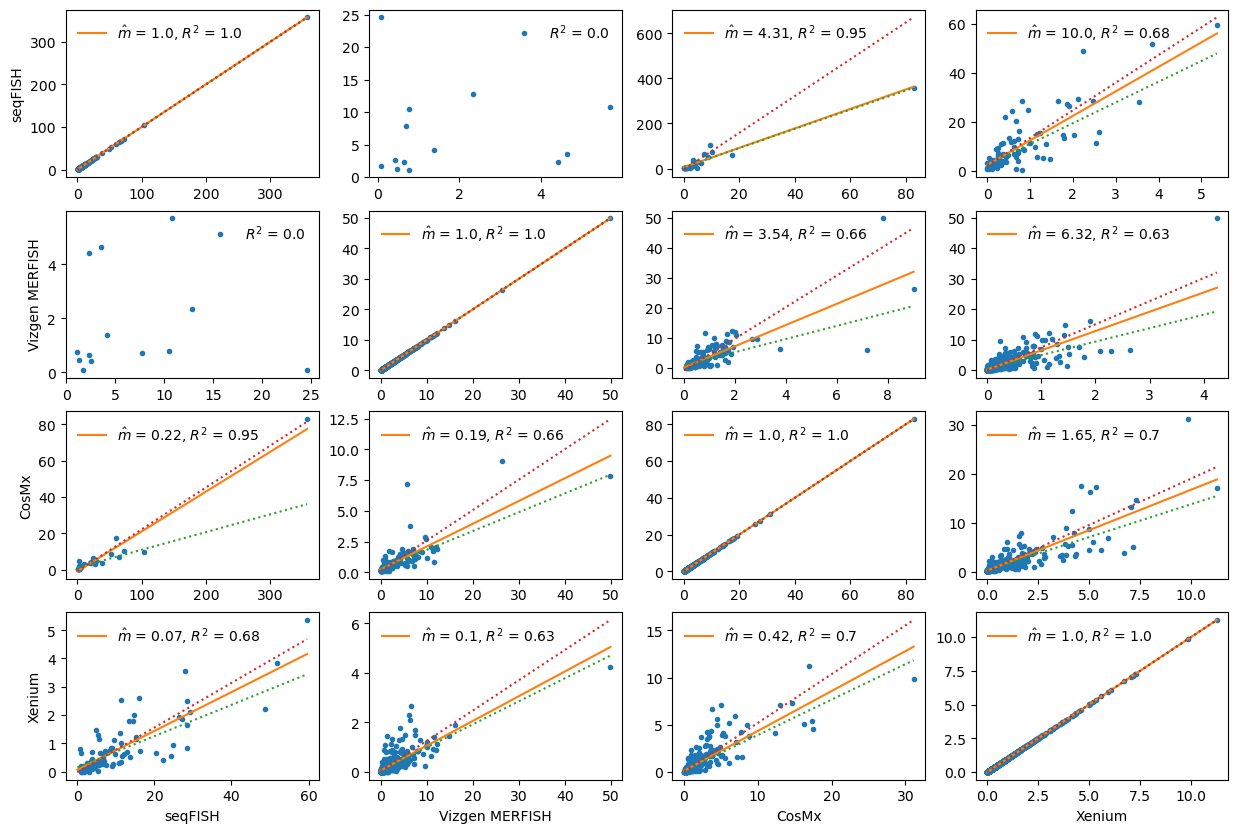

In [20]:

fig, ax = plt.subplots(4,4, figsize= [15,10])
for i, method_i in enumerate(method_results):
    ax[i,0].set_ylabel(method_i)
    ax[3,i].set_xlabel(method_i)
    for j, method_j in enumerate(method_results):
        matched_genes = pd.DataFrame({method_i: method_results[method_i], method_j : method_results[method_j]}).dropna()
        fit = linregress(matched_genes[method_i], matched_genes[method_j])
        
        if fit.rvalue**2 > 0.1:
            boot_res = bootstrap(matched_genes)
            #print(method_i, method_j)
            #print(bounds)
            ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.')
            slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
            r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
            label_text = slope_label + r_sq_label
            ax[j,i].plot([0, np.max(matched_genes[method_i])], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes[method_i])], label = label_text)
            ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[0], boot_res['intercept'].iloc[0] + boot_res['slope'].iloc[0] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{l}$ = " + str(np.round(boot_res['slope'].iloc[0],2)))
            ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[1], boot_res['intercept'].iloc[1] + boot_res['slope'].iloc[1] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{u}$ = " + str(np.round(boot_res['slope'].iloc[1],2)))
            boot_res['intercept'].iloc[0]
        else:
            ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.', label=r"$R^2$ = " + str(np.round(fit.rvalue**2, 2)))
        ax[j,i].legend(frameon=False)

plt.savefig("sup_cortex_benchmark.pdf")